In [1]:
import sys
import os
import time
import numpy as np

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [8]:
#ChatGPT prompt:
# write a python function which takes a matrix of histogram bin counts or densities and two 1d arrays with axis values as its arguments, 
# masks the matrix to show bins with zero count in grey, and plots a 2d histogram (as if from plt.hist2d) of the values

#see also https://stackoverflow.com/questions/50420553/setting-range-of-colors-in-pcolormesh 

def plot_hist2d_from_matrix(H, xvals, yvals, ax=None, cmap="viridis"):
    """
    Plot a 2D histogram from a matrix of bin counts/densities, masking zeros in grey.

    Parameters
    ----------
    H : (ny, nx) array
        Matrix of histogram counts or densities.
    xvals : (nx+1) or (nx,) array
        Bin edges or bin centers along x.
    yvals : (ny+1) or (ny,) array
        Bin edges or bin centers along y.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (creates one if None).
    cmap : str or Colormap
        Colormap for nonzero bins.
    """

    H = np.asarray(H)

    # Mask zero bins
    Hmasked = np.ma.masked_where(H == 0, H)

    if ax is None:
        fig, ax = plt.subplots()

    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgrey")

    norm = mpl.colors.Normalize(vmin=0, vmax=0.4)

    mesh = ax.pcolormesh(xvals, yvals, Hmasked, cmap=cmap, norm=norm)
    plt.colorbar(mesh, ax=ax, label="P(z | bin)", norm=norm)

    ax.set_xlabel("Ligand distance from bound pose (Å)")
    ax.set_ylabel("Ligand z coordinate\nrelative to membrane center (Å)")

    plt.show()

    return ax

In [9]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 3

data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-2",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-2"]
data_path = data_paths[run_ind]

final_rounds = [2000,1000,2000,2000]
final_round = final_rounds[run_ind]

In [117]:
def plot_to_subplot(data_path, h5path, final_round, axs, fig, splt, labels):
    
    pcs_all = load_h5_pcs(h5path, minround, maxround)

    pcs_all_processed = []
    ligz_all = []
    rounds_all = []
    walkers_all = []

    #later init_round values avoid questions about confounding time correlations but increase statistical noise
    init_round = 0
    #final_round = 1000
    #loop over WE rounds
    for r in range(init_round+1,final_round,10):
        
        #get progress coordinates of the walkers, accounting for the occasional corrupted file
        pcs_flat = pcs_all[r-1][:,-1].flatten()
        walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
        pcs = [pcs_flat[w] for w in walkers]

        #assign frames to bins by pc
        #bins = np.digitize(pcs, binbounds)

        #load water coordinates
        lig_coords = np.load(f"{data_path}/pc_data_round_{r}_ligand_pos_unaligned_v1.npy")

        if len(walkers) != len(lig_coords):
            print(f"upstream data processing error for round {r}")
            continue

        phos_z = np.load(f"{data_path}/pc_data_round_{r}_phosphate_z_means_v1.npy")

        #print(phos_z)
        #break

        ligz = np.mean(lig_coords[:,:,2], axis = 1)-(phos_z[:,2] + phos_z[:,3])/2

        pcs_all_processed += pcs
        ligz_all += list(ligz)
        rounds_all += [r for a in range(len(walkers))]
        walkers_all += list(walkers)

    #make histogram of probability density in each bin
    lig_z_pc_hist = np.histogramdd((pcs_all_processed, ligz_all), range=[[0, 40],[-20, 20]], bins = [40,40])
    bin_normalized_density = lig_z_pc_hist[0]/lig_z_pc_hist[0].sum(axis=1, keepdims=True)

    ####################################################################
    #                            PLOTTING                              #
    ####################################################################

    #plot_hist2d_from_matrix(bin_normalized_density.transpose(), lig_z_pc_hist[1][0], lig_z_pc_hist[1][1], ax=None, cmap="viridis")

    #H = np.asarray(H)
    H = bin_normalized_density.transpose()
    xvals = lig_z_pc_hist[1][0]
    yvals = lig_z_pc_hist[1][1]
    cmap="viridis"

    # Mask zero bins
    Hmasked = np.ma.masked_where(H == 0, H)

    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgrey")

    norm = mpl.colors.Normalize(vmin=0, vmax=0.5)

    mesh = axs[splt].pcolormesh(xvals, yvals, Hmasked, cmap=cmap, norm=norm)
    axs[splt].set_aspect("equal")

    if splt == (1,1):
        #see https://www.geeksforgeeks.org/data-visualization/how-to-have-one-colorbar-for-all-subplots-in-matplotlib/ 
        fig.subplots_adjust(right=0.8)
        cbar_ax = fig.add_axes([0.85, 0.05, 0.05, 0.7])
        fig.colorbar(mesh, cax=cbar_ax, norm=norm, label="P(z | bin)")
        
    if splt[0] == 1:
        axs[splt].set_xlabel("Ligand distance from bound pose (Å)")
    if splt[1] == 0:
        axs[splt].set_ylabel("Ligand z coordinate\nrelative to membrane center (Å)")

    title_elements = data_path.split("/")[-1].split("-")
    if title_elements[0] == "abbv":
        ti0 = "ABBV"
    elif title_elements[0] == "cftri":
        ti0 = "CFTRi"
        
    axs[splt].set_title(f"{ti0}-{title_elements[1].upper()} run {title_elements[2]}")
    letters = ["A","B","C","D"]
    print(letters[splt[0]+2*splt[1]])
    axs[splt].annotate(letters[splt[0]+2*splt[1]], (2, 15), fontsize=24)

upstream data processing error for round 1951
upstream data processing error for round 1991
A
B
C
upstream data processing error for round 1501
upstream data processing error for round 1711
D


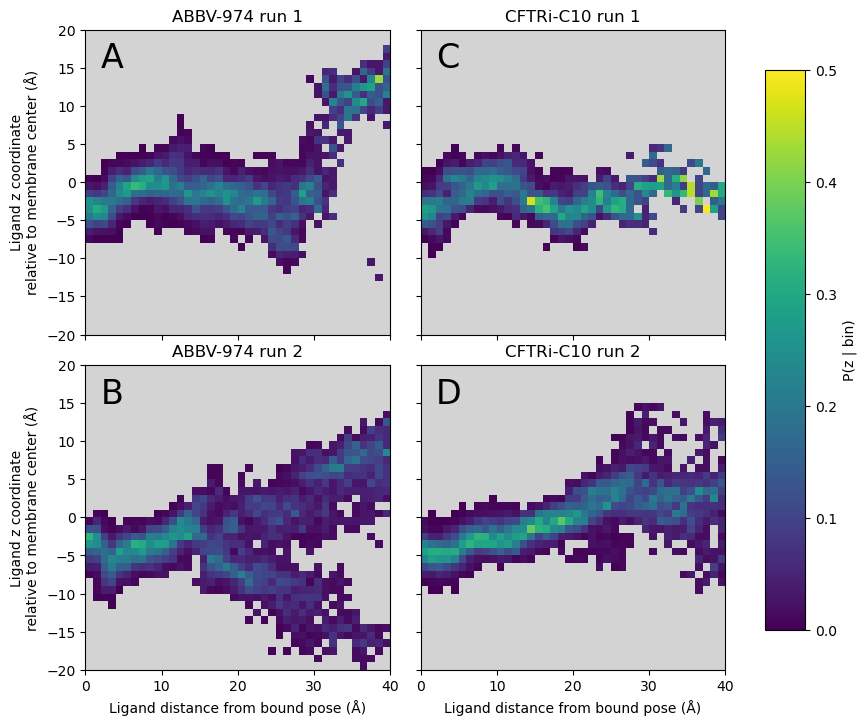

In [118]:
fig, axs = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(8, 8))

dlabels = ["ligand pyrazole NH to Glu 873", "ligand alcohol OH to Glu 873"]
alabels = ["ligand pyrazole N: to Arg 933", "ligand alcohol O: to Arg 933"]

maxrounds = [2000,1000,2000,2000]
for run_ind in range(4):
    x = run_ind%2
    y = run_ind//2
    data_path = data_paths[run_ind]
    h5path = h5paths_names[run_ind][0]
    plot_to_subplot(data_path, h5path, maxrounds[run_ind], axs, fig, (x,y), (dlabels[y], alabels[y]))

plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.8, bottom=0, left=0, right=0.8)

#plt.tight_layout() #incompatible with colorbar
plt.savefig("/home/jonathan/Documents/grabelab/cftr/revisions/z_distributions.svg", format="svg", bbox_inches="tight")

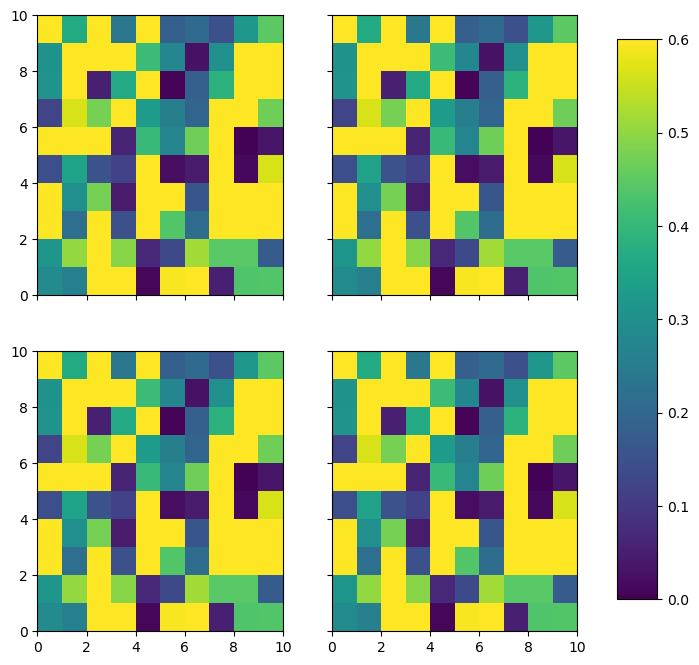

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', figsize=(8, 8))

data = np.random.rand(10, 10)
for i, ax in enumerate(axes.flat):
    cmap="viridis"
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgrey")
    norm = mpl.colors.Normalize(vmin=0, vmax=0.6)

    im = ax.pcolormesh([i for i in range(11)], [i for i in range(11)], data, cmap=cmap, norm=norm)

    #im = ax.imshow(data, norm=norm, cmap='viridis')

    if i == 0:
        fig.subplots_adjust(right=0.8)
        cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
        fig.colorbar(im, cax=cbar_ax, norm=norm)

plt.show()